In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
base_dir = r"C:\Users\user\python-class\pneumonia\chest_xray"
train_dir = os.path.join(base_dir,"train")
test_dir = os.path.join(base_dir,"test")
val_dir = os.path.join(base_dir,"val")

IMG_SIZE = 224
BATCH_SIZE = 32

In [5]:
#printing length of each directory

print("----------Train dataset----------")
print("Number of training images: ", len(os.listdir(train_dir)))
print("Number of normal images in training set: ", len(os.listdir(os.path.join(train_dir,"NORMAL"))))
print("Number of pneumonia images in training set: ", len(os.listdir(os.path.join(train_dir, "PNEUMONIA"))))

print("----------Test dataset----------")

print("Number of testing images: ", len(os.listdir(test_dir)))
print("Number of normal images in test set: ", len(os.listdir(os.path.join(test_dir,"NORMAL"))))
print("Number of pneumonia images in test set: ", len(os.listdir(os.path.join(test_dir, "PNEUMONIA"))))

print("----------validation dataset----------")
print("Number of validation images: ", len(os.listdir(val_dir)))
print("number of normal images in validation set: ", len(os.listdir(os.path.join(val_dir,"NORMAL"))))
print("number of pneumonia images in validation set: ", len(os.listdir(os.path.join(val_dir, "PNEUMONIA"))))
print("---------------------------------------")

def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))
    return normal, pneumonia

train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)

print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)


----------Train dataset----------
Number of training images:  2
Number of normal images in training set:  1341
Number of pneumonia images in training set:  3875
----------Test dataset----------
Number of testing images:  2
Number of normal images in test set:  234
Number of pneumonia images in test set:  390
----------validation dataset----------
Number of validation images:  2
number of normal images in validation set:  8
number of pneumonia images in validation set:  8
---------------------------------------
Train: (1341, 3875)
Val: (8, 8)
Test: (234, 390)


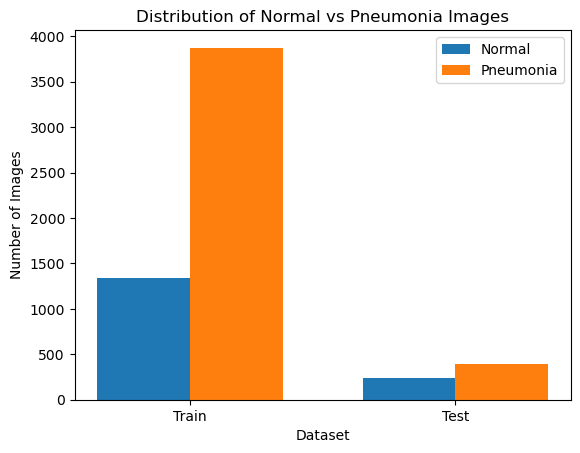

In [23]:
#bar plot of pneumonia vs normal in each dataset
datasets = ['Train', 'Test']
normal_counts = [train_counts[0],  test_counts[0]]
pneumonia_counts = [train_counts[1], test_counts[1]]
x = np.arange(len(datasets))
width = 0.35
plt.bar(x - width/2, normal_counts, width, label='Normal')
plt.bar(x + width/2, pneumonia_counts, width, label='Pneumonia')
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Distribution of Normal vs Pneumonia Images')
plt.xticks(x, datasets)
plt.legend()
plt.show()


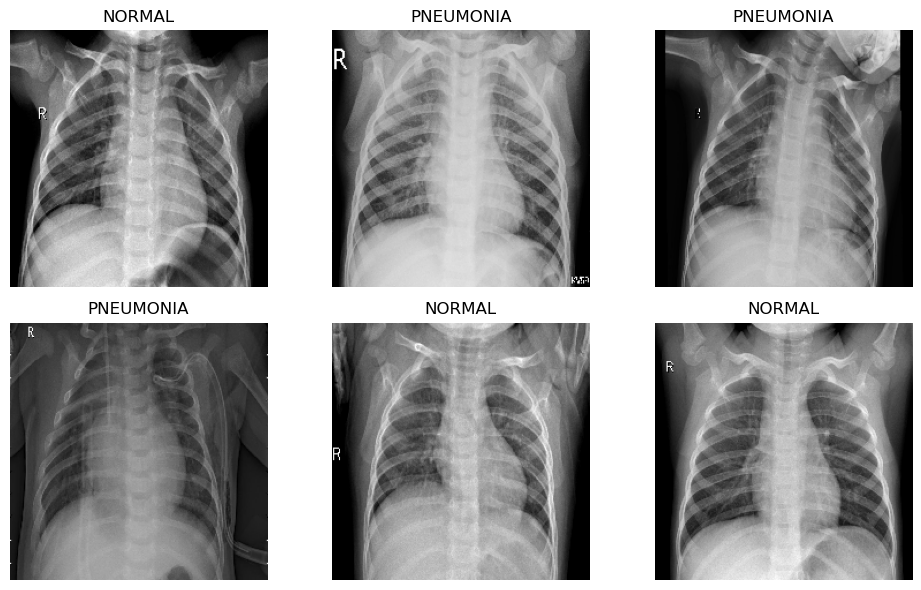

In [6]:
import random
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    class_name = random.choice(["NORMAL", "PNEUMONIA"])
    img_path = os.path.join(train_dir, class_name,
                             random.choice(os.listdir(os.path.join(train_dir, class_name))))
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

checkpoint_cnn = ModelCheckpoint(
    "best_cnn_model.h5",
    save_best_only=True
)

checkpoint_mobilenet = ModelCheckpoint(
    "best_mobilenet_model.h5",
    save_best_only=True
)

In [24]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint_cnn]
)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint_mobilenet]
)

NameError: name 'early_stop' is not defined

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator)
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_generator)

print("CNN Accuracy:", cnn_acc)
print("MobileNet Accuracy:", mobilenet_acc)

In [ ]:
preds = mobilenet_model.predict(test_generator)
pred_labels = (preds > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, pred_labels)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(test_generator.classes, pred_labels))

In [ ]:
fpr, tpr, thresholds = roc_curve(test_generator.classes, preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()